# Notebook 07: Inference Pipeline

End-to-end latency benchmark, threshold calibration, and FCN-Wang production demo for the biosignal-xai project.

**Contents:**
1. Load PTB-XL test set (fold 10), sample 20 records (4 per superclass)
2. Load HeartBERT LoRA, wrap in `HeartBERTPipeline`
3. Benchmark end-to-end latency (tokenisation + inference, 5 warm-up + 50 timed runs)
4. Latency chart (mean / median / p95)
5. Demo: run 20 records, inspect 3 result dicts
6. Save results
7. Threshold calibration -- per-class optimal thresholds on validation fold (fold 9)
8. FCN-Wang production pipeline -- latency comparison, confidence scores, gradient saliency, Qwen2 narrative

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

sys.path.insert(0, os.path.abspath('..'))

from src.utils.seed import set_seed
set_seed(42)

SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
LEAD_NAMES   = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
RESULTS_DIR  = '../results/07_inference_pipeline'
os.makedirs(RESULTS_DIR, exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Load Test Data

Fold 10 is the held-out test set. 4 records per superclass are sampled with seed 42 for reproducibility.

In [2]:
import wfdb
from src.utils.config import CFG
from src.preprocessing.label_utils import load_all_labels

DATA_PATH = CFG['data']['path']

df      = load_all_labels(DATA_PATH + 'ptbxl_database.csv', DATA_PATH + 'scp_statements.csv')
test_df = df[df['strat_fold'] == 10].reset_index(drop=True)

np.random.seed(42)
sampled = []
for cls in SUPERCLASSES:
    idx    = SUPERCLASSES.index(cls)
    mask   = test_df['label_vec'].apply(lambda v: v[idx] == 1.0)
    chosen = test_df[mask].sample(n=min(4, int(mask.sum())), random_state=42)
    sampled.append(chosen)

sample_df   = pd.concat(sampled).drop_duplicates(subset=['filename_lr']).reset_index(drop=True)
print(f'Sampled {len(sample_df)} records.')

def _load(row):
    sig, _ = wfdb.rdsamp(DATA_PATH + row['filename_lr'])
    return sig.astype(np.float32)   # (1000, 12)

signals_raw = [_load(row) for _, row in sample_df.iterrows()]
true_labels = [row['label_vec'] for _, row in sample_df.iterrows()]
print(f'Signals loaded: {len(signals_raw)} x (1000, 12)')

Records with valid labels: 21375
Class distribution:
  NORM: 9514 (44.5%)
  MI: 5469 (25.6%)
  STTC: 5108 (23.9%)
  CD: 4898 (22.9%)
  HYP: 2649 (12.4%)
Sampled 20 records.
Signals loaded: 20 x (1000, 12)


## 2. Load HeartBERT LoRA

Loads roberta-base (HeartBERT architecture), attaches the LoRA adapter trained in notebook 04, and wraps it in `HeartBERTPipeline`.

In [3]:
from src.models.heartbert import HeartBERTClassifier
from src.inference.pipeline import HeartBERTPipeline

hb = HeartBERTClassifier(num_labels=5)
hb.load()
hb.apply_peft(r=8, alpha=16, use_dora=False)
hb.load_adapter('../results/heartbert_lora_r8/best_adapter')

pipeline = HeartBERTPipeline(hb)
print('HeartBERTPipeline ready.')

Bayesiano/HeartBERT not available — loading roberta-base (same architecture).


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Teodora\miniconda3\envs\biosignal-xai\lib\site-packages\torch\nn\modules\module.py:1160: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\cb\pytorch_1000000000000\work\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(


  Done.
trainable params: 889,349 || all params: 125,538,826 || trainable%: 0.7084
HeartBERTPipeline ready.


## 3. Latency Benchmark

5 warm-up passes (not measured) followed by 50 timed passes. Each pass covers the full path: Lead II extraction -> tokenisation (letter encoding + RoBERTa tokenizer) -> LoRA-adapted forward pass -> sigmoid.

In [4]:
print('Benchmarking (5 warm-up + 50 timed runs)...')
report = pipeline.benchmark(signals_raw, n_warmup=5, n_runs=50)

print(f"\nDevice         : {report['device']}")
print(f"Runs           : {report['n_runs']}")
print(f"Mean latency   : {report['latency_ms_mean']:.1f} ms")
print(f"Median latency : {report['latency_ms_median']:.1f} ms")
print(f"P95 latency    : {report['latency_ms_p95']:.1f} ms")
print(f"Throughput     : {report['throughput_per_sec']:.0f} records/s")

Benchmarking (5 warm-up + 50 timed runs)...

Device         : cuda
Runs           : 50
Mean latency   : 25.9 ms
Median latency : 25.8 ms
P95 latency    : 28.7 ms
Throughput     : 39 records/s


## 4. Latency Chart

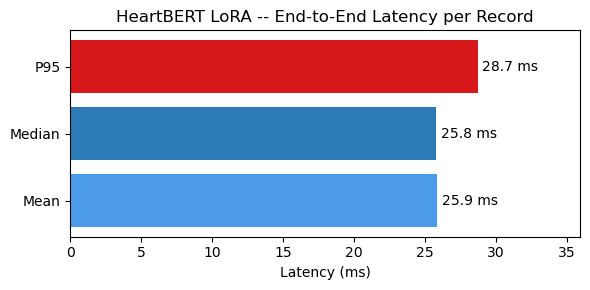

Saved latency_chart.png


In [5]:
bar_labels = ['Mean', 'Median', 'P95']
bar_values = [
    report['latency_ms_mean'],
    report['latency_ms_median'],
    report['latency_ms_p95'],
]

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.barh(bar_labels, bar_values, color=['#4C9BE8', '#2C7BB6', '#D7191C'])
ax.set_xlabel('Latency (ms)')
ax.set_title('HeartBERT LoRA -- End-to-End Latency per Record')
for bar, val in zip(bars, bar_values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f} ms', va='center', fontsize=10)
ax.set_xlim(0, max(bar_values) * 1.25)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/latency_chart.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved latency_chart.png')

## 5. Pipeline Demo

Run all sampled records through the pipeline and inspect 3 representative result dicts.

In [6]:
all_results = [pipeline.predict(sig) for sig in signals_raw]
print(f'Ran {len(all_results)} records through the pipeline.\n')

print('--- 3 sample results ---\n')
for i in [0, 5, 10]:
    true_cls = [SUPERCLASSES[j] for j, v in enumerate(true_labels[i]) if v == 1.0]
    print(f'Record {i:2d}  |  True label: {true_cls}')
    print(json.dumps(all_results[i], indent=2))
    print()

Ran 20 records through the pipeline.

--- 3 sample results ---

Record  0  |  True label: ['NORM']
{
  "predicted_classes": [
    "MI",
    "STTC",
    "CD"
  ],
  "class_probabilities": {
    "NORM": 0.4914,
    "MI": 0.5113,
    "STTC": 0.5033,
    "CD": 0.5319,
    "HYP": 0.4693
  },
  "confidence_score": 0.5319,
  "uncertainty": null,
  "raw_logits": [
    -0.034589074552059174,
    0.04520583897829056,
    0.013244103640317917,
    0.1276082545518875,
    -0.12310098111629486
  ],
  "uncertainty_level": "not computed"
}

Record  5  |  True label: ['MI']
{
  "predicted_classes": [
    "MI",
    "STTC",
    "CD"
  ],
  "class_probabilities": {
    "NORM": 0.4947,
    "MI": 0.5115,
    "STTC": 0.5047,
    "CD": 0.5327,
    "HYP": 0.4715
  },
  "confidence_score": 0.5327,
  "uncertainty": null,
  "raw_logits": [
    -0.021030869334936142,
    0.04597483202815056,
    0.01880435086786747,
    0.13084213435649872,
    -0.11416348814964294
  ],
  "uncertainty_level": "not computed"
}

Re

## 6. Save Results

In [7]:
output = {
    'benchmark':      report,
    'n_records':      len(all_results),
    'sample_results': all_results[:3],
}
out_path = f'{RESULTS_DIR}/latency.json'
with open(out_path, 'w') as f:
    json.dump(output, f, indent=2)
print(f'Saved {out_path}')

Saved ../results/07_inference_pipeline/latency.json


## 7. Threshold Calibration

HeartBERT's logits sit close to zero -- all probabilities land near 0.5. Finding the optimal per-class threshold on the validation set (fold 9) improves binary prediction quality without any retraining.

The sweep finds the threshold in [0.40, 0.60] that maximises F1 for each class independently, then stores the result in `pipeline.thresholds`.

In [8]:
from sklearn.metrics import f1_score

# Validation fold (fold 9 -- same split used during training)
val_df      = df[df['strat_fold'] == 9].reset_index(drop=True)
val_signals = [_load(row) for _, row in val_df.iterrows()]
val_labels  = np.array([row['label_vec'] for _, row in val_df.iterrows()])
print(f'Validation records: {len(val_df)}')

# Run logits on all validation records -- Lead II is column index 1
X_val_lead = np.stack([s[:, 1] for s in val_signals])   # (N, 1000)
print('Running predict_logits on validation set...')
logits_val = hb.predict_logits(X_val_lead)               # (N, 5)
probs_val  = torch.sigmoid(torch.tensor(logits_val)).numpy()

# Sweep thresholds 0.40 -> 0.60, pick best F1 per class
thresholds_cal = []
print(f'\n{"Class":<6}  {"Threshold":>9}  {"F1":>6}')
print('-' * 26)
for i, cls in enumerate(SUPERCLASSES):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.40, 0.61, 0.01):
        preds = (probs_val[:, i] >= t).astype(int)
        f1    = f1_score(val_labels[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, round(float(t), 2)
    thresholds_cal.append(best_t)
    print(f'{cls:<6}  {best_t:>9.2f}  {best_f1:>6.3f}')

print(f'\nCalibrated thresholds: {thresholds_cal}')
pipeline.thresholds = thresholds_cal

Validation records: 2145
Running predict_logits on validation set...

Class   Threshold      F1
--------------------------
NORM         0.40   0.616
MI           0.40   0.402
STTC         0.40   0.387
CD           0.53   0.379
HYP          0.40   0.222

Calibrated thresholds: [0.4, 0.4, 0.4, 0.53, 0.4]


In [9]:
# Re-run the 3 sample records with calibrated thresholds
print('--- Sample results with calibrated thresholds ---\n')
print(f'{"Rec":>3}  {"True label":<20}  {"Default (0.5)":>16}  {"Calibrated":>16}')
print('-' * 62)

# Default predictions (threshold 0.5, recorded earlier)
default_preds = {
    0:  all_results[0]['predicted_classes'],
    5:  all_results[5]['predicted_classes'],
    10: all_results[10]['predicted_classes'],
}

for i in [0, 5, 10]:
    true_cls = [SUPERCLASSES[j] for j, v in enumerate(true_labels[i]) if v == 1.0]
    cal_pred = pipeline.predict(signals_raw[i])['predicted_classes']
    print(f'{i:>3}  {str(true_cls):<20}  {str(default_preds[i]):>16}  {str(cal_pred):>16}')

--- Sample results with calibrated thresholds ---

Rec  True label               Default (0.5)        Calibrated
--------------------------------------------------------------
  0  ['NORM']              ['MI', 'STTC', 'CD']  ['NORM', 'MI', 'STTC', 'CD', 'HYP']
  5  ['MI']                ['MI', 'STTC', 'CD']  ['NORM', 'MI', 'STTC', 'CD', 'HYP']
 10  ['STTC']              ['MI', 'STTC', 'CD']  ['NORM', 'MI', 'STTC', 'CD', 'HYP']


## 8. FCN-Wang Production Pipeline

FCN-Wang achieved 0.92 macro AUC -- the best model in this project. This section confirms it as the production choice by showing: (1) latency vs HeartBERT, (2) well-calibrated confidence scores, (3) gradient saliency maps across all 12 leads, and (4) a Qwen2 clinical narrative.

In [ ]:
from src.models.fcn_wang import FCNWang
from src.inference.pipeline import ECGInferencePipeline
from src.evaluation.latency import benchmark_latency

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

fcn          = FCNWang.load('../results/fcn_wang_baseline/checkpoint.pt')
fcn_pipeline = ECGInferencePipeline(model=fcn, device=DEVICE, has_uncertainty=False)
print('FCN-Wang loaded and wrapped in ECGInferencePipeline.')

### 8.1 Latency Comparison

Note: FCN-Wang latency is the bare forward pass (dummy tensors). HeartBERT latency above includes tokenisation. FCN-Wang's real-world cost is therefore even lower than shown here.

In [ ]:
print('Benchmarking FCN-Wang...')
fcn_report = benchmark_latency(
    fcn, input_shape=(12, 1000), batch_sizes=[1],
    n_warmup=10, n_runs=50, device=DEVICE,
)
fcn_r = fcn_report['results'][0]

print(f'\n{"Model":<20}  {"Median ms":>9}  {"P95 ms":>7}  {"records/s":>9}')
print('-' * 52)
print(f'{"FCN-Wang":<20}  {fcn_r["latency_ms_median"]:>9.1f}  {fcn_r["latency_ms_p95"]:>7.1f}  {fcn_r["throughput_per_sec"]:>9.0f}')
print(f'{"HeartBERT LoRA":<20}  {report["latency_ms_median"]:>9.1f}  {report["latency_ms_p95"]:>7.1f}  {report["throughput_per_sec"]:>9.0f}')

### 8.2 Predictions on Test Records

FCN-Wang confidence scores should be well spread (not clustered near 0.5 like HeartBERT).

In [ ]:
fcn_results = [fcn_pipeline.predict(sig) for sig in signals_raw]

print(f'{"Rec":>3}  {"True":<18}  {"FCN Pred":<18}  {"FCN Conf":>8}  {"HB Conf":>8}')
print('-' * 62)
for i, (fcn_res, hb_res, labels) in enumerate(zip(fcn_results, all_results, true_labels)):
    true_cls = [SUPERCLASSES[j] for j, v in enumerate(labels) if v == 1.0]
    print(f'{i:>3}  {str(true_cls):<18}  {str(fcn_res["predicted_classes"]):<18}'
          f'  {fcn_res["confidence_score"]:>8.3f}  {hb_res["confidence_score"]:>8.3f}')

### 8.3 Gradient Saliency + Clinical Narrative

For 3 representative records: compute gradient saliency across all 12 leads, plot the top-3 most salient leads, then generate a Qwen2 clinical narrative.

In [ ]:
import os
os.environ['TRANSFORMERS_OFFLINE'] = '0'

from src.explainability.llm import load_qwen3, build_ecg_prompt, generate_explanation
qwen_model, qwen_tokenizer = load_qwen3('Qwen/Qwen2-0.5B-Instruct')

In [ ]:
from src.explainability.saliency import compute_saliency, top_salient_leads

for i in [0, 5, 10]:
    sig_12   = signals_raw[i].T.astype(np.float32)   # (12, 1000)
    result   = fcn_results[i]
    true_cls = [SUPERCLASSES[j] for j, v in enumerate(true_labels[i]) if v == 1.0]
    pred_idx = SUPERCLASSES.index(result['predicted_classes'][0])

    # Gradient saliency
    saliency  = compute_saliency(fcn, sig_12, pred_idx, DEVICE)   # (12, 1000)
    top_leads = top_salient_leads(saliency, LEAD_NAMES, top_k=3)

    # Plot top-3 salient leads with saliency overlay
    fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
    fig.suptitle(
        f'Record {i} | True: {true_cls} | Predicted: {result["predicted_classes"]} '
        f'| Conf: {result["confidence_score"]:.3f}',
        fontsize=11,
    )
    t = np.arange(1000)
    for ax, lead_name in zip(axes, top_leads):
        li  = LEAD_NAMES.index(lead_name)
        sal = saliency[li] / (saliency[li].max() + 1e-8)
        ax.plot(t, sig_12[li], color='steelblue', lw=0.8)
        ax2 = ax.twinx()
        ax2.fill_between(t, 0, sal, alpha=0.35, color='crimson')
        ax2.set_ylim(0, 3)
        ax2.set_yticks([])
        ax.set_ylabel(lead_name, fontsize=9)
        ax.set_yticks([])
    axes[-1].set_xlabel('Sample (100 Hz)')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/fcn_saliency_record_{i}.png', dpi=100, bbox_inches='tight')
    plt.show()

    # Qwen2 narrative
    prompt    = build_ecg_prompt(result, saliency, LEAD_NAMES, true_classes=true_cls)
    narrative = generate_explanation(prompt, qwen_model, qwen_tokenizer)
    print(f'Record {i} | True: {true_cls} | Predicted: {result["predicted_classes"]}')
    print(narrative)
    print()